# Relações, correlação e associação

**Tema:** Preparação de Dados › Análise Exploratória (EDA)

Este notebook percorre a tabela do `teoria.pdf`: Pearson, Spearman,
qui-quadrado/Cramér's V, ANOVA/eta² e informação mútua — cada um aplicado ao
par de variáveis para o qual foi desenhado, e cada um "falhando" de forma
instrutiva quando usado fora do seu domínio.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.feature_selection import mutual_info_regression

rng = np.random.default_rng(21)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
print("pronto")

pronto


## 1. Pearson vs. Spearman: quando a relação é monotônica mas não linear

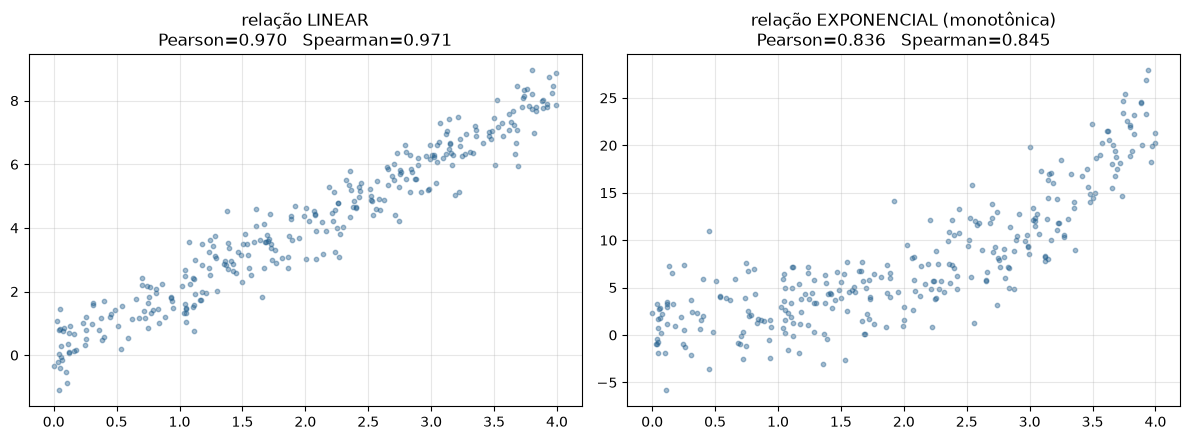

Na relação exponencial, Spearman captura a monotonicidade quase perfeita;
Pearson subestima porque a curva se afasta de uma reta.


In [2]:
x = rng.uniform(0, 4, 300)
y_linear = 2 * x + rng.normal(0, 0.6, 300)
y_exponencial = np.exp(x * 0.8) + rng.normal(0, 3, 300)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, y, nome in [(axes[0], y_linear, "relação LINEAR"),
                    (axes[1], y_exponencial, "relação EXPONENCIAL (monotônica)")]:
    pearson = stats.pearsonr(x, y).statistic
    spearman = stats.spearmanr(x, y).statistic
    ax.scatter(x, y, s=10, alpha=0.4, color=AZUL)
    ax.set_title(f"{nome}\nPearson={pearson:.3f}   Spearman={spearman:.3f}")
plt.tight_layout(); plt.show()

print("Na relação exponencial, Spearman captura a monotonicidade quase perfeita;")
print("Pearson subestima porque a curva se afasta de uma reta.")

## 2. Quando nem Spearman resolve: relação em U

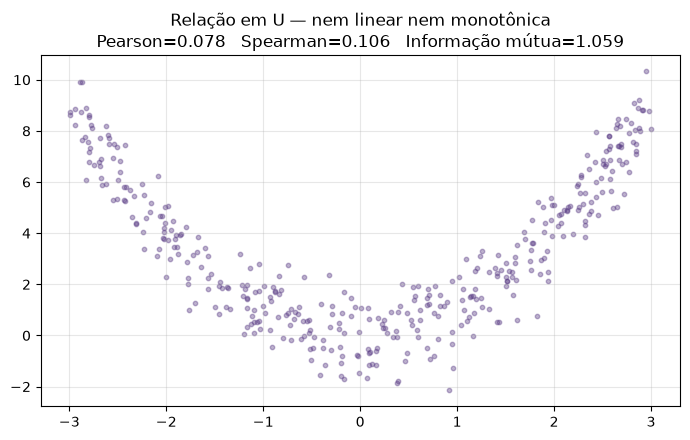

Pearson e Spearman dizem 'quase sem relação'. A relação existe e é forte
— só não é linear nem monotônica. Informação mútua é a única que enxerga.


In [3]:
x_u = rng.uniform(-3, 3, 400)
y_u = x_u**2 + rng.normal(0, 1, 400)

pearson_u = stats.pearsonr(x_u, y_u).statistic
spearman_u = stats.spearmanr(x_u, y_u).statistic
mi_u = mutual_info_regression(x_u.reshape(-1, 1), y_u, random_state=0)[0]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(x_u, y_u, s=10, alpha=0.4, color=ROXO)
ax.set_title(f"Relação em U — nem linear nem monotônica\n"
            f"Pearson={pearson_u:.3f}   Spearman={spearman_u:.3f}   "
            f"Informação mútua={mi_u:.3f}")
plt.tight_layout(); plt.show()

print("Pearson e Spearman dizem 'quase sem relação'. A relação existe e é forte")
print("— só não é linear nem monotônica. Informação mútua é a única que enxerga.")

## 3. Qui-quadrado e Cramér's V: duas categóricas

In [4]:
n = 2000
regiao = rng.choice(["Norte", "Sul", "Sudeste", "Nordeste"], n,
                     p=[0.1, 0.25, 0.45, 0.2])
# plano escolhido depende da região (associação real, não independente)
probs_por_regiao = {
    "Norte": [0.5, 0.3, 0.2], "Sul": [0.2, 0.3, 0.5],
    "Sudeste": [0.15, 0.25, 0.6], "Nordeste": [0.4, 0.35, 0.25],
}
plano = np.array([rng.choice(["básico", "intermediário", "premium"], p=probs_por_regiao[r])
                  for r in regiao])

tabela_contingencia = pd.crosstab(regiao, plano)
print("tabela de contingência:")
print(tabela_contingencia)

chi2, p_valor, gl, esperado = stats.chi2_contingency(tabela_contingencia)
n_total = tabela_contingencia.values.sum()
r, k = tabela_contingencia.shape
cramers_v = np.sqrt((chi2 / n_total) / min(r - 1, k - 1))

print(f"\nqui-quadrado = {chi2:.2f}   p-valor = {p_valor:.2e}   "
      f"graus de liberdade = {gl}")
print(f"Cramér's V = {cramers_v:.4f}   (0=independente, 1=associação perfeita)")

tabela de contingência:
col_0     básico  intermediário  premium
row_0                                   
Nordeste     172            159      110
Norte        104             57       36
Sudeste      138            220      515
Sul           88            146      255

qui-quadrado = 257.95   p-valor = 8.21e-53   graus de liberdade = 6
Cramér's V = 0.2539   (0=independente, 1=associação perfeita)


## 4. Cramér's V não depende do tamanho da amostra (ao contrário do qui²)

In [5]:
def cramers_v(tab):
    chi2, _, _, _ = stats.chi2_contingency(tab)
    n_total = tab.values.sum()
    r, k = tab.shape
    return np.sqrt((chi2 / n_total) / min(r - 1, k - 1))


tamanhos = [200, 1000, 5000, 20000]
print(f"{'n':>8s} {'qui-quadrado':>14s} {'Cramér V':>12s}")
print("-" * 36)
for tam in tamanhos:
    reg = rng.choice(["Norte", "Sul", "Sudeste", "Nordeste"], tam,
                     p=[0.1, 0.25, 0.45, 0.2])
    pln = np.array([rng.choice(["básico", "intermediário", "premium"],
                               p=probs_por_regiao[r]) for r in reg])
    tab = pd.crosstab(reg, pln)
    chi2_val, _, _, _ = stats.chi2_contingency(tab)
    print(f"{tam:>8d} {chi2_val:>14.1f} {cramers_v(tab):>12.4f}")

print("\nO qui-quadrado CRESCE com n (mesmo padrão de associação, número maior).")
print("Cramér's V fica estável — é a medida certa para comparar força de")
print("associação entre datasets de tamanhos diferentes.")

       n   qui-quadrado     Cramér V
------------------------------------
     200           26.6       0.2580
    1000          136.1       0.2608
    5000          613.2       0.2476


   20000         2364.7       0.2431

O qui-quadrado CRESCE com n (mesmo padrão de associação, número maior).
Cramér's V fica estável — é a medida certa para comparar força de
associação entre datasets de tamanhos diferentes.


## 5. ANOVA e eta²: categórica × numérica

ANOVA F = 3859.48   p-valor = 0.00e+00
eta² = 0.9172   (91.7% da variância do salário é explicada pelo nível)


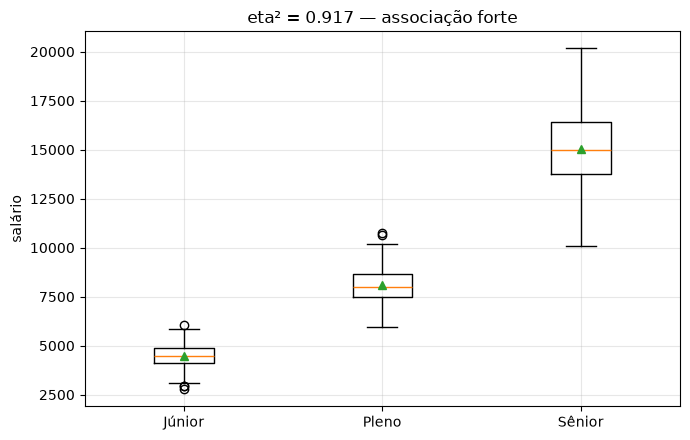

In [6]:
nivel = np.array((["Júnior"] * 300) + (["Pleno"] * 250) + (["Sênior"] * 150))
salario = np.concatenate([
    rng.normal(4500, 500, 300), rng.normal(8000, 900, 250), rng.normal(15000, 2000, 150),
])

grupos = [salario[nivel == g] for g in ["Júnior", "Pleno", "Sênior"]]
f_estat, p_valor = stats.f_oneway(*grupos)

media_geral = salario.mean()
sq_entre = sum(len(g) * (g.mean() - media_geral) ** 2 for g in grupos)
sq_total = np.sum((salario - media_geral) ** 2)
eta2 = sq_entre / sq_total

print(f"ANOVA F = {f_estat:.2f}   p-valor = {p_valor:.2e}")
print(f"eta² = {eta2:.4f}   ({eta2:.1%} da variância do salário é explicada pelo nível)")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.boxplot(grupos, tick_labels=["Júnior", "Pleno", "Sênior"], showmeans=True)
ax.set_ylabel("salário"); ax.set_title(f"eta² = {eta2:.3f} — associação forte")
plt.tight_layout(); plt.show()

## 6. O paradoxo de Simpson, reproduzido

Construção deliberada: dentro de cada departamento, o Grupo B tem taxa de
aprovação **maior**. Agregado, o Grupo A parece favorecido — porque o Grupo A
se concentra no departamento mais fácil.

In [7]:
departamentos = pd.DataFrame([
    {"departamento": "Fácil",  "grupo": "A", "candidatos": 800, "aprovados": 680},
    {"departamento": "Fácil",  "grupo": "B", "candidatos": 100, "aprovados": 90},
    {"departamento": "Difícil", "grupo": "A", "candidatos": 100, "aprovados": 20},
    {"departamento": "Difícil", "grupo": "B", "candidatos": 800, "aprovados": 200},
])
departamentos["taxa_aprovacao"] = departamentos["aprovados"] / departamentos["candidatos"]
print("por departamento:")
print(departamentos.to_string(index=False))

agregado = departamentos.groupby("grupo")[["candidatos", "aprovados"]].sum()
agregado["taxa_aprovacao"] = agregado["aprovados"] / agregado["candidatos"]
print("\nagregado (ignorando departamento):")
print(agregado.round(3).to_string())

por departamento:
departamento grupo  candidatos  aprovados  taxa_aprovacao
       Fácil     A         800        680            0.85
       Fácil     B         100         90            0.90
     Difícil     A         100         20            0.20
     Difícil     B         800        200            0.25

agregado (ignorando departamento):
       candidatos  aprovados  taxa_aprovacao
grupo                                       
A             900        700           0.778
B             900        290           0.322


**Leitura:** em CADA departamento, o Grupo B tem taxa de aprovação maior
(90% vs. 85% no Fácil; 25% vs. 20% no Difícil). Mas agregado, o Grupo A
parece favorecido (76,7% vs. 32,2%) — porque 800 dos 900 candidatos do Grupo
A estão no departamento Fácil, e o oposto para o Grupo B. A variável
escondida (departamento) inverte a conclusão.

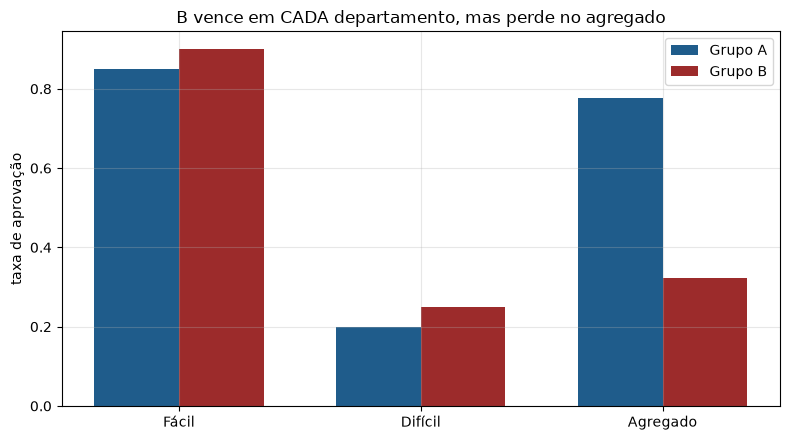

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
x_pos = np.arange(3)
labels = ["Fácil", "Difícil", "Agregado"]
taxa_a = [departamentos.query("departamento=='Fácil' and grupo=='A'")["taxa_aprovacao"].iloc[0],
          departamentos.query("departamento=='Difícil' and grupo=='A'")["taxa_aprovacao"].iloc[0],
          agregado.loc["A", "taxa_aprovacao"]]
taxa_b = [departamentos.query("departamento=='Fácil' and grupo=='B'")["taxa_aprovacao"].iloc[0],
          departamentos.query("departamento=='Difícil' and grupo=='B'")["taxa_aprovacao"].iloc[0],
          agregado.loc["B", "taxa_aprovacao"]]
largura = 0.35
ax.bar(x_pos - largura / 2, taxa_a, largura, label="Grupo A", color=AZUL)
ax.bar(x_pos + largura / 2, taxa_b, largura, label="Grupo B", color=VERMELHO)
ax.set_xticks(x_pos); ax.set_xticklabels(labels)
ax.set_ylabel("taxa de aprovação")
ax.set_title("B vence em CADA departamento, mas perde no agregado")
ax.legend(); plt.tight_layout(); plt.show()

## O que levar deste notebook

- Pearson mede só relação linear; Spearman generaliza para monotônica;
  informação mútua não assume nenhuma forma — e cada uma tem seu lugar.
- Cramér's V corrige a dependência do qui-quadrado ao tamanho da amostra;
  é a medida comparável entre datasets.
- eta² quantifica o quanto uma categórica explica da variância de uma
  numérica — a mesma decomposição de soma de quadrados do tema 2.
- O paradoxo de Simpson é real e comum: sempre verifique se uma conclusão
  agregada se sustenta dentro dos subgrupos relevantes antes de reportá-la.

→ Próximo: o notebook de **exercícios** do módulo.